# Matching LDA organizations with IRS records

The analysis connects organizations reported in LDA lobbying filings with IRS Form 990 records stored as Parquet files in S3.

Organizations are evaluated separately according to their role in each filing: client, registrant, or affiliate. Names are normalized before exact and Jaro-Winkler comparisons are run against the IRS organization table.

Match strength is based on the available supporting evidence:

- name
- name and state
- name, state, and 5-digit ZIP

These links should be treated as review candidates, not confirmed identities.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_BASE = "s3://irs-990-263839540825-us-east-2-an/parquet_updated"
AWS_REGION = "us-east-2"

conn = duckdb.connect(database=":memory:")
conn.execute("INSTALL httpfs; LOAD httpfs;")
# Cache Parquet footers / HTTP metadata so S3 reads aren't re-globbed every query.
conn.execute("SET enable_object_cache=true;")
conn.execute("SET enable_http_metadata_cache=true;")
conn.execute(f"""
    CREATE SECRET s3_access (
        TYPE s3,
        PROVIDER credential_chain,
        REGION '{AWS_REGION}'
    )
""")

for table in (
    "organizations",
    "irs_master",
    "irs990_filings",
    "irs990_filing_related_orgs",
    "irs990_filing_527_orgs",
    "lda_filings",
    "entity_observations",
):
    conn.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_parquet(
            '{PARQUET_BASE}/{table}/*.parquet',
            union_by_name = true
        )
    """)

def q(sql):
    return conn.execute(sql).df()

coverage = q("""
SELECT 1 AS sort_order, 'Form 990 e-file organization EINs' AS metric,
       COUNT(DISTINCT ein) AS value
FROM organizations
UNION ALL
SELECT 2, 'EINs in current loaded IRS master extract', COUNT(DISTINCT ein)
FROM irs_master
UNION ALL
SELECT 3, 'Current IRS master EINs with state', COUNT(DISTINCT ein)
FROM irs_master
WHERE NULLIF(TRIM(state), '') IS NOT NULL
UNION ALL
SELECT 4, 'Form 990 filing EINs with filing state', COUNT(DISTINCT ein)
FROM irs990_filings
WHERE NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '') IS NOT NULL
UNION ALL
SELECT 5, 'Schedule R related-org EINs with state',
       COUNT(DISTINCT ein)
FROM irs990_filing_related_orgs
WHERE NULLIF(TRIM(ein), '') IS NOT NULL
  AND NULLIF(TRIM(state_code), '') IS NOT NULL
UNION ALL
SELECT 6, '527-org EINs with state', COUNT(DISTINCT ein)
FROM irs990_filing_527_orgs
WHERE NULLIF(TRIM(ein), '') IS NOT NULL
  AND NULLIF(TRIM(state_code), '') IS NOT NULL
UNION ALL
SELECT 7, 'LDA filings', COUNT(*) FROM lda_filings
UNION ALL
SELECT 8, 'LDA filings with client state', COUNT(*)
FROM lda_filings
WHERE json_valid(raw_json)
  AND NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '') IS NOT NULL
UNION ALL
SELECT 9, 'Distinct LDA client IDs',
       COUNT(DISTINCT json_extract_string(raw_json, '$.client.id'))
FROM lda_filings WHERE json_valid(raw_json)
UNION ALL
SELECT 10, 'Distinct LDA client IDs with state',
       COUNT(DISTINCT CASE
           WHEN NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '') IS NOT NULL
           THEN json_extract_string(raw_json, '$.client.id') END)
FROM lda_filings WHERE json_valid(raw_json)
ORDER BY sort_order
""").drop(columns="sort_order")

print(f"DuckDB reading updated Parquet from: {PARQUET_BASE}")
coverage.style.format({"value": "{:,.0f}"})


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DuckDB reading updated Parquet from: s3://irs-990-263839540825-us-east-2-an/parquet_updated


,metric,value
0,Form 990 e-file organization EINs,"861,081"
1,EINs in current loaded IRS master extract,"279,802"
2,Current IRS master EINs with state,"279,802"
3,Form 990 filing EINs with filing state,"860,890"
4,Schedule R related-org EINs with state,"193,996"
5,527-org EINs with state,"10,530"
6,LDA filings,"192,174"
7,LDA filings with client state,"186,203"
8,Distinct LDA client IDs,"28,790"
9,Distinct LDA client IDs with state,"27,845"


In [2]:
import re as _re

# Shared helpers so the matching cells below don't repeat the same logic:
#   NEAR_NAME_MIN_SIMILARITY - single source of truth for the near-name cutoff
#   ZIP_SCORE_MIN - minimum graduated ZIP-proximity score treated as corroborating
#   norm_org      - org-name normalization matching extract/entities.py
#   name_block_on - blocked Jaro-Winkler join predicate (shared 8-char prefix + length ratio)
#   zip_score_on  - graduated USPS ZIP-proximity score (100/90/80/0) over candidate ZIPs
#   tier_case     - name / name+state / name+state+zip label from zip_agrees / state_agrees
NEAR_NAME_MIN_SIMILARITY = 0.85
ZIP_SCORE_MIN = 80  # 80 = shared first-3 digits (USPS Sectional Center Facility / metro area)

_NOISE = {
    "inc", "incorporated", "llc", "lp", "llp", "corp", "corporation",
    "the", "of", "and", "for", "a", "an", "pac", "cmte", "association", "committee", "fund", "foundation", "trust", "club"
}

def _norm_org(name):
    if not name:
        return ""
    tokens = _re.sub(r"[^a-z0-9\s]", " ", name.lower()).split()
    return " ".join(t for t in tokens if t not in _NOISE)

try:
    conn.create_function("norm_org", _norm_org, ["VARCHAR"], "VARCHAR")
except Exception:
    pass  # already registered in this kernel

def name_block_on(a, b):
    """Blocking predicate for near-name joins: shared 8-char prefix and >=60% length ratio."""
    return (
        f"LEFT({a}, 8) = LEFT({b}, 8)\n"
        f"     AND LEAST(LENGTH({a}), LENGTH({b}))::DOUBLE\n"
        f"         / GREATEST(LENGTH({a}), LENGTH({b})) >= 0.60"
    )

def zip_score_on(irs_zip, *lda_zips):
    """Graduated USPS ZIP-proximity score, best over the candidate ZIPs.

    100 = exact 5-digit, 90 = shared first 4, 80 = shared first 3 (Sectional
    Center Facility / metro area), 0 = further apart or either ZIP missing.
    """
    parts = [
        (
            f"CASE WHEN {irs_zip} IS NOT NULL AND {z} IS NOT NULL THEN "
            f"CASE WHEN {irs_zip} = {z} THEN 100 "
            f"WHEN LEFT({irs_zip}, 4) = LEFT({z}, 4) THEN 90 "
            f"WHEN LEFT({irs_zip}, 3) = LEFT({z}, 3) THEN 80 "
            f"ELSE 0 END ELSE 0 END"
        )
        for z in lda_zips
    ]
    return "GREATEST(" + ", ".join(parts) + ")"

def tier_case(prefix="name"):
    """Strongest-evidence label from the zip_agrees / state_agrees booleans."""
    return (
        "CASE "
        f"WHEN zip_agrees THEN '{prefix} + state + zip' "
        f"WHEN state_agrees THEN '{prefix} + state' "
        f"ELSE '{prefix} only' END"
    )


In [3]:
# IRS EIN-level entities: name, normalized name, and best-available state.
# State is the latest Form 990 filer_state, else the BMF master state. Schedule R and
# 527 states are ignored on purpose -- they describe other orgs named in a filing, not the filer.
conn.execute("""
CREATE OR REPLACE TEMP TABLE irs_entities AS
WITH ranked_filing_states AS (
    SELECT
        ein,
        UPPER(NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '')) AS filing_state,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY
                COALESCE( tax_period_end_date, CAST(tax_year AS VARCHAR)) DESC,
                filing_id DESC
        ) AS state_recency
    FROM irs990_filings
    WHERE NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '') IS NOT NULL
    AND form_type NOT IN ('990T','990PF')
), filing_states AS (
    SELECT ein, filing_state FROM ranked_filing_states WHERE state_recency = 1
)
SELECT
    organization.ein,
    organization.current_name AS irs_name,
    organization.normalized_name,
    COALESCE(
        filing.filing_state,
        UPPER(NULLIF(TRIM(master.state), ''))
    ) AS irs_state
FROM organizations AS organization
LEFT JOIN filing_states AS filing USING (ein)
LEFT JOIN irs_master AS master USING (ein)
WHERE organization.normalized_name IS NOT NULL
  AND organization.normalized_name <> ''
""")

print("IRS entities:", f"{q('SELECT COUNT(*) AS n FROM irs_entities').iloc[0]['n']:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IRS entities: 861,079


## Building the LDA organization list

Filings are retained when they report lobbying income or expenses. One organization record is created for each role: client, registrant, or affiliate.

LDA client records do not normally expose ZIP codes through the API. The `client_zip.csv` file in S3 contains addresses recovered from historical filing HTML. Both address slots are normalized to 5-digit U.S. ZIP codes and validated against the filing's client state or principal-place-of-business state. A stable ZIP is then selected for each client ID and state using the most frequently observed value. When two ZIPs have equal support, the lower ZIP is selected deterministically.

The recovered client-state map is applied to the fee-bearing filing cohort. Existing self-filing registrant ZIPs remain as a fallback when no state-consistent recovered ZIP is available. This prevents ZIPs from being transferred across clients or states while increasing the number of client organizations that can be checked using name, state, and ZIP agreement.

In [4]:
# Build a state-validated client ZIP map from all recovered filing addresses.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE recovered_client_zip AS
WITH all_client_filings AS (
    SELECT
        filing_uuid,
        json_extract_string(raw_json, '$.client.id') AS client_id,
        UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '')) AS client_state,
        UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.ppb_state')), '')) AS client_ppb_state
    FROM lda_filings
    WHERE json_valid(raw_json)
), recovery_source AS MATERIALIZED (
    SELECT *
    FROM read_csv_auto(
        's3://irs-990-263839540825-us-east-2-an/client_zip.csv',
        header=true,
        all_varchar=true
    )
), recovery_addresses AS (
    SELECT
        source.filing_uuid,
        source.client_id,
        UPPER(NULLIF(TRIM(address.state), '')) AS recovered_state,
        NULLIF(regexp_extract(TRIM(address.zip), '([0-9]{{5}})', 1), '') AS recovered_zip5,
        UPPER(NULLIF(TRIM(address.country), '')) AS recovered_country
    FROM recovery_source AS source,
    UNNEST([
        STRUCT_PACK(state := source.state_1, zip := source.zip_1, country := source.country_1),
        STRUCT_PACK(state := source.state_2, zip := source.zip_2, country := source.country_2)
    ]) AS unpacked(address)
), validated AS (
    SELECT
        filing.client_id,
        address.recovered_state,
        address.recovered_zip5
    FROM all_client_filings AS filing
    JOIN recovery_addresses AS address
      ON address.filing_uuid = filing.filing_uuid
     AND address.client_id = filing.client_id
     AND address.recovered_state IN (filing.client_state, filing.client_ppb_state)
    WHERE address.recovered_zip5 IS NOT NULL
      AND COALESCE(address.recovered_country, 'USA') IN ('USA', 'US', 'UNITED STATES')
), zip_frequency AS (
    SELECT
        client_id,
        recovered_state,
        recovered_zip5,
        COUNT(*) AS observations
    FROM validated
    GROUP BY client_id, recovered_state, recovered_zip5
), ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY client_id, recovered_state
               ORDER BY observations DESC, recovered_zip5
           ) AS zip_rank
    FROM zip_frequency
)
SELECT client_id, recovered_state, recovered_zip5, observations
FROM ranked
WHERE zip_rank = 1
""")

conn.execute("""
CREATE OR REPLACE TEMP TABLE lda_fee_filings AS
SELECT
    filing_uuid,
    json_extract_string(raw_json, '$.client.id')   AS client_id,
    json_extract_string(raw_json, '$.client.name') AS client_name,
    norm_org(json_extract_string(raw_json, '$.client.name'))     AS client_norm,      -- normalize once, reused below
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '')) AS client_state,
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.ppb_state')), '')) AS client_ppb_state,
    json_extract_string(raw_json, '$.registrant.id')   AS registrant_id,
    json_extract_string(raw_json, '$.registrant.name') AS registrant_name,
    norm_org(json_extract_string(raw_json, '$.registrant.name')) AS registrant_norm,  -- normalize once, reused below
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.registrant_state')), '')) AS registrant_state,
    LEFT(NULLIF(TRIM(json_extract_string(raw_json, '$.registrant_zip')), ''), 5) AS registrant_zip5,
    raw_json
FROM lda_filings
WHERE json_valid(raw_json)
  AND (COALESCE(income, 0) > 0 OR COALESCE(expenses, 0) > 0)
""")

# One candidate per (role, org) with the org's normalized name and available location.
# Each recovered ZIP is kept in the column paired with the state it was validated against:
# lda_zip goes with lda_state (client_state), lda_ppb_zip goes with lda_ppb_state. The self-filing
# fallbacks stay on the primary lda_zip. State agreement is required before any recovered ZIP is used.
conn.execute("""
CREATE OR REPLACE TEMP TABLE lda_org_candidates AS
WITH self_filed_zip AS (
    SELECT client_norm,
           registrant_state AS self_state,
           mode(registrant_zip5) AS self_zip5
    FROM lda_fee_filings
    WHERE client_norm = registrant_norm
      AND registrant_zip5 IS NOT NULL
      AND registrant_state IS NOT NULL
    GROUP BY client_norm, registrant_state
), client_role AS (
    SELECT
        'client' AS role,
        filing.client_id AS lda_key,
        filing.client_name AS lda_name,
        filing.client_norm AS normalized_name,
        filing.client_state AS lda_state,
        filing.client_ppb_state AS lda_ppb_state,
        -- ZIP paired with lda_state (client_state); the ppb-state ZIP is kept separate below.
        COALESCE(
            state_zip.recovered_zip5,
            CASE WHEN filing.client_norm = filing.registrant_norm
                 THEN filing.registrant_zip5 END,
            self_zip.self_zip5
        ) AS lda_zip,
        ppb_zip.recovered_zip5 AS lda_ppb_zip,   -- ZIP paired with lda_ppb_state
        CASE
            WHEN state_zip.recovered_zip5 IS NOT NULL
              OR ppb_zip.recovered_zip5 IS NOT NULL THEN 'client_zip.csv'
            WHEN filing.client_norm = filing.registrant_norm
                 AND filing.registrant_zip5 IS NOT NULL THEN 'self-filing registrant'
            WHEN self_zip.self_zip5 IS NOT NULL THEN 'self-filing fallback'
        END AS lda_zip_source
    FROM lda_fee_filings AS filing
    LEFT JOIN recovered_client_zip AS state_zip
      ON state_zip.client_id = filing.client_id
     AND state_zip.recovered_state = filing.client_state
    LEFT JOIN recovered_client_zip AS ppb_zip
      ON ppb_zip.client_id = filing.client_id
     AND ppb_zip.recovered_state = filing.client_ppb_state
     AND ppb_zip.recovered_state IS DISTINCT FROM filing.client_state
    LEFT JOIN self_filed_zip AS self_zip
      ON self_zip.client_norm = filing.client_norm
     AND self_zip.self_state IN (filing.client_state, filing.client_ppb_state)
), registrant_role AS (
    -- Registrant record carries a stable LDA registrant.id; the name is kept as the display label.
    SELECT
        'registrant'                AS role,
        registrant_id               AS lda_key,
        registrant_name             AS lda_name,
        registrant_norm             AS normalized_name,
        registrant_state            AS lda_state,
        NULL                        AS lda_ppb_state,
        registrant_zip5             AS lda_zip,
        NULL                        AS lda_ppb_zip,
        'registrant filing'         AS lda_zip_source
    FROM lda_fee_filings
), affiliate_role AS (
    -- Affiliates carry no LDA id (free-text array), so the name is used for both lda_key and lda_name.
    SELECT
        'affiliate'                                                                  AS role,
        json_extract_string(affiliate.value, '$.name')                               AS lda_key,
        json_extract_string(affiliate.value, '$.name')                               AS lda_name,
        norm_org(json_extract_string(affiliate.value, '$.name'))                     AS normalized_name,
        UPPER(NULLIF(TRIM(json_extract_string(affiliate.value, '$.state')), ''))     AS lda_state,
        UPPER(NULLIF(TRIM(json_extract_string(affiliate.value, '$.ppb_state')), '')) AS lda_ppb_state,
        LEFT(NULLIF(TRIM(json_extract_string(affiliate.value, '$.zip')), ''), 5)     AS lda_zip,
        NULL                                                                         AS lda_ppb_zip,
        'affiliate filing'                                                           AS lda_zip_source
    FROM lda_fee_filings,
         json_each(json_extract(raw_json, '$.affiliated_organizations')) AS affiliate
)
SELECT DISTINCT *
FROM (
    SELECT * FROM client_role
    UNION ALL SELECT * FROM registrant_role
    UNION ALL SELECT * FROM affiliate_role
) AS all_roles
WHERE normalized_name IS NOT NULL
  AND LEN(STRING_SPLIT(normalized_name, ' ')) >= 2
""")

candidate_counts = q("""
SELECT role,
       COUNT(*) AS candidate_rows,
       COUNT(DISTINCT lda_key) AS distinct_orgs,
       COUNT(DISTINCT lda_key) FILTER (WHERE lda_zip IS NOT NULL OR lda_ppb_zip IS NOT NULL) AS orgs_with_zip,
       COUNT(DISTINCT lda_key) FILTER (WHERE lda_zip_source = 'client_zip.csv') AS orgs_with_recovered_zip
FROM lda_org_candidates
GROUP BY role
ORDER BY role
""")
candidate_counts.style.format({
    "candidate_rows": "{:,.0f}",
    "distinct_orgs": "{:,.0f}",
    "orgs_with_zip": "{:,.0f}",
    "orgs_with_recovered_zip": "{:,.0f}",
})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,role,candidate_rows,distinct_orgs,orgs_with_zip,orgs_with_recovered_zip
0,affiliate,279,275,259,0
1,client,"20,872","20,698","10,107","5,729"
2,registrant,"4,722","4,335","4,316",0


In [5]:
# IRS entities with a 5-digit ZIP from their most recent filing, for ZIP agreement.
conn.execute("""
CREATE OR REPLACE TEMP TABLE irs_entities_addr AS
WITH latest AS (
    SELECT
        ein,
        LEFT(NULLIF(TRIM(CAST(filer_zip AS VARCHAR)), ''), 5) AS filer_zip5,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY COALESCE( tax_period_end_date, CAST(tax_year AS VARCHAR)) DESC,
                     filing_id DESC
        ) AS rn
    FROM irs990_filings
    WHERE NULLIF(TRIM(CAST(filer_zip AS VARCHAR)), '') IS NOT NULL
)
SELECT irs.ein, irs.irs_name, irs.normalized_name, irs.irs_state,
       latest.filer_zip5 AS irs_zip
FROM irs_entities AS irs
LEFT JOIN latest ON latest.ein = irs.ein AND latest.rn = 1
""")

conn.execute(f"""
CREATE OR REPLACE TEMP TABLE role_matches AS
SELECT
    cand.role,
    cand.lda_key,
    cand.lda_name,
    cand.normalized_name,
    cand.lda_state,
    cand.lda_ppb_state,
    COALESCE(cand.lda_zip, cand.lda_ppb_zip) AS lda_zip,   -- single null-safe ZIP for downstream
    cand.lda_zip_source,
    irs.ein,
    irs.irs_name,
    irs.irs_state,
    irs.irs_zip,
    (irs.irs_state IN (cand.lda_state, cand.lda_ppb_state)
        AND irs.irs_state IS NOT NULL) AS state_agrees,
    -- ZIP agrees if the IRS ZIP matches the client-state ZIP or the ppb-state ZIP (mirrors state_agrees).
    (irs.irs_zip IN (cand.lda_zip, cand.lda_ppb_zip)
        AND irs.irs_zip IS NOT NULL) AS zip_agrees,
    -- Graduated ZIP proximity (100 exact / 90 first-4 / 80 first-3 / 0 further), best over both ZIPs.
    {zip_score_on('irs.irs_zip', 'cand.lda_zip', 'cand.lda_ppb_zip')} AS zip_score
FROM lda_org_candidates AS cand
JOIN irs_entities_addr AS irs USING (normalized_name)
""")

# Counts use distinct normalized_name (the join unit); lda_key is heterogeneous across roles.
role_match_summary = q("""
SELECT
    role,
    COUNT(DISTINCT normalized_name) AS matched_orgs,
    COUNT(DISTINCT ein) AS irs_eins,
    COUNT(DISTINCT normalized_name) FILTER (WHERE state_agrees) AS state_agree_orgs,
    COUNT(DISTINCT normalized_name) FILTER (WHERE zip_agrees) AS zip_agree_orgs,
    COUNT(DISTINCT normalized_name) FILTER (
        WHERE zip_agrees AND lda_zip_source = 'client_zip.csv'
    ) AS recovered_zip_agree_orgs
FROM role_matches
GROUP BY role
ORDER BY role
""")
role_match_summary.style.format({
    "matched_orgs": "{:,.0f}",
    "irs_eins": "{:,.0f}",
    "state_agree_orgs": "{:,.0f}",
    "zip_agree_orgs": "{:,.0f}",
    "recovered_zip_agree_orgs": "{:,.0f}",
})


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,role,matched_orgs,irs_eins,state_agree_orgs,zip_agree_orgs,recovered_zip_agree_orgs
0,affiliate,24,25,22,18,0
1,client,"2,180","4,039","1,873",941,523
2,registrant,653,"1,861",550,503,0


## Near-name matching by role

The `role_matches` table contains exact normalized-name matches. This section adds near-name candidates for clients, registrants, and affiliates using the following rules:

- the first eight normalized characters must match
- the shorter name must be at least 60% of the longer name
- Jaro-Winkler similarity must be at least `NEAR_NAME_MIN_SIMILARITY` (0.85)
- exact matches are excluded because they already appear in `role_matches`

State (`state` or `ppb_state`) and 5-digit ZIP agreement are then added as supporting evidence. Near-name matches without geographic agreement remain candidates for manual review.

In [6]:
# Score blocked near-name pairs once, then add geographic evidence.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE role_near_matches AS
WITH scored AS (
    SELECT
        candidate.role,
        candidate.lda_key,
        candidate.lda_name,
        candidate.normalized_name AS lda_normalized_name,
        candidate.lda_state,
        candidate.lda_ppb_state,
        COALESCE(candidate.lda_zip, candidate.lda_ppb_zip) AS lda_zip,   -- single null-safe ZIP for downstream
        candidate.lda_ppb_zip,
        candidate.lda_zip_source,
        irs.ein,
        irs.irs_name,
        irs.normalized_name AS irs_normalized_name,
        irs.irs_state,
        irs.irs_zip,
        jaro_winkler_similarity(
            candidate.normalized_name,
            irs.normalized_name
        ) AS name_similarity
    FROM lda_org_candidates AS candidate
    JOIN irs_entities_addr AS irs
      ON {name_block_on('candidate.normalized_name', 'irs.normalized_name')}
     AND candidate.normalized_name <> irs.normalized_name
)
SELECT
    * EXCLUDE lda_ppb_zip,
    (irs_state IN (lda_state, lda_ppb_state) AND irs_state IS NOT NULL) AS state_agrees,
    -- ZIP agrees if the IRS ZIP matches the client-state ZIP or the ppb-state ZIP (mirrors state_agrees).
    (irs_zip IN (lda_zip, lda_ppb_zip) AND irs_zip IS NOT NULL) AS zip_agrees,
    -- Graduated ZIP proximity (100 exact / 90 first-4 / 80 first-3 / 0 further), best over both ZIPs.
    {zip_score_on('irs_zip', 'lda_zip', 'lda_ppb_zip')} AS zip_score
FROM scored
WHERE name_similarity >= {NEAR_NAME_MIN_SIMILARITY}
""")

role_near_summary = q("""
SELECT
    role,
    CASE
        WHEN state_agrees AND zip_agrees THEN 'state and ZIP agree'
        WHEN state_agrees THEN 'state only'
        WHEN zip_agrees THEN 'ZIP only'
        ELSE 'name only'
    END AS evidence,
    COUNT(*) AS candidate_links,
    COUNT(DISTINCT lda_key) AS lda_organizations,
    COUNT(DISTINCT ein) AS irs_eins,
    ROUND(AVG(name_similarity), 3) AS average_similarity
FROM role_near_matches
GROUP BY role, evidence
ORDER BY
    CASE evidence
        WHEN 'state and ZIP agree' THEN 1
        WHEN 'state only' THEN 2
        WHEN 'ZIP only' THEN 3
        ELSE 4
    END,
    role
""")

display(role_near_summary.style.format({
    "candidate_links": "{:,.0f}",
    "lda_organizations": "{:,.0f}",
    "irs_eins": "{:,.0f}",
    "average_similarity": "{:.3f}",
}))


,role,evidence,candidate_links,lda_organizations,irs_eins,average_similarity
0,affiliate,state and ZIP agree,107,33,98,0.876
1,client,state and ZIP agree,"10,536","2,440","3,323",0.875
2,registrant,state and ZIP agree,"4,203",884,"2,119",0.874
3,affiliate,state only,"1,301",45,"1,216",0.866
4,client,state only,"222,342","6,975","49,288",0.867
5,registrant,state only,"42,450","1,207","16,074",0.866
6,affiliate,ZIP only,21,14,21,0.884
7,client,ZIP only,403,287,237,0.881
8,registrant,ZIP only,103,96,75,0.879
9,affiliate,name only,"20,049",104,"12,509",0.865


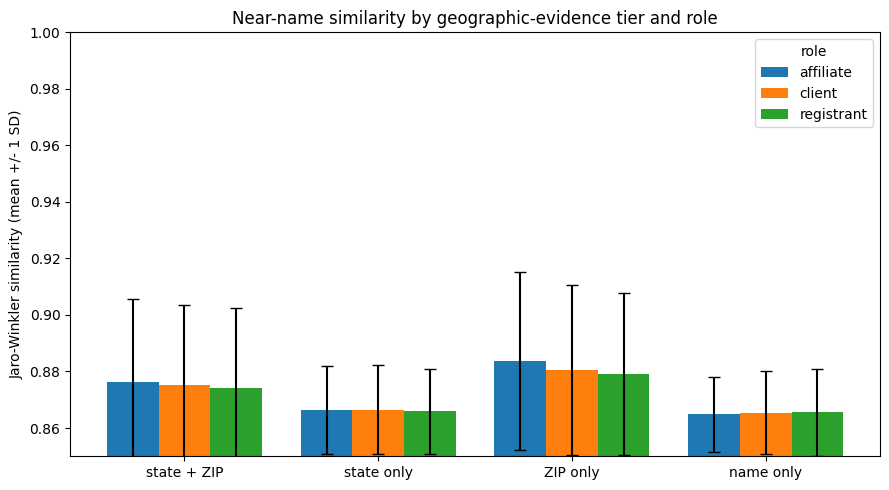

In [7]:
# Visualize near-name similarity by evidence tier and role (mean +/- 1 SD).
import numpy as np
import matplotlib.pyplot as plt

near_sim_stats = q("""
SELECT
    role,
    CASE
        WHEN state_agrees AND zip_agrees THEN 'state + ZIP'
        WHEN state_agrees THEN 'state only'
        WHEN zip_agrees THEN 'ZIP only'
        ELSE 'name only'
    END AS evidence,
    COUNT(*) AS n,
    AVG(name_similarity) AS mean_sim,
    STDDEV_SAMP(name_similarity) AS std_sim
FROM role_near_matches
GROUP BY role, evidence
""")

evidence_order = ['state + ZIP', 'state only', 'ZIP only', 'name only']
roles = sorted(near_sim_stats['role'].unique())
mean_p = near_sim_stats.pivot(index='evidence', columns='role', values='mean_sim').reindex(evidence_order)
std_p = near_sim_stats.pivot(index='evidence', columns='role', values='std_sim').reindex(evidence_order).fillna(0)

x = np.arange(len(evidence_order))
width = 0.8 / max(len(roles), 1)
fig, ax = plt.subplots(figsize=(9, 5))
for i, role in enumerate(roles):
    ax.bar(x + i * width, mean_p[role], width, yerr=std_p[role], capsize=4, label=role)
ax.set_xticks(x + width * (len(roles) - 1) / 2)
ax.set_xticklabels(evidence_order)
ax.set_ylabel("Jaro-Winkler similarity (mean +/- 1 SD)")
ax.set_title("Near-name similarity by geographic-evidence tier and role")
ax.set_ylim(NEAR_NAME_MIN_SIMILARITY, 1.0)
ax.legend(title="role")
plt.tight_layout()
plt.show()


In [8]:
# Diagnose LDA organizations with no exact or near-name IRS candidate.
unmatched_lda_orgs = q("""
WITH matched_keys AS (
    SELECT role, lda_key FROM role_matches
    UNION
    SELECT role, lda_key FROM role_near_matches
)
SELECT
    candidate.role,
    candidate.lda_key,
    any_value(candidate.lda_name) AS lda_name,
    any_value(candidate.normalized_name) AS normalized_name,
    mode(candidate.lda_state) AS lda_state,
    mode(candidate.lda_ppb_state) AS lda_ppb_state,
    mode(candidate.lda_zip) FILTER (WHERE candidate.lda_zip IS NOT NULL) AS lda_zip,
    mode(candidate.lda_zip_source) FILTER (
        WHERE candidate.lda_zip_source IS NOT NULL
    ) AS lda_zip_source,
    COUNT(*) AS candidate_rows
FROM lda_org_candidates AS candidate
ANTI JOIN matched_keys AS matched
  ON matched.role = candidate.role
 AND matched.lda_key = candidate.lda_key
GROUP BY candidate.role, candidate.lda_key
ORDER BY candidate.role, lda_name, candidate.lda_key
""")

unmatched_summary = (
    unmatched_lda_orgs.groupby("role", dropna=False)
    .agg(
        unmatched_orgs=("lda_key", "nunique"),
        orgs_with_state=("lda_state", lambda values: values.notna().sum()),
        orgs_with_zip=("lda_zip", lambda values: values.notna().sum()),
        recovered_zip_orgs=(
            "lda_zip_source",
            lambda values: values.eq("client_zip.csv").sum(),
        ),
    )
)

# Retain the best blocked IRS comparison even when it falls below the near-name cutoff.
conn.register("unmatched_lda_review", unmatched_lda_orgs)
unmatched_with_irs = q(f"""
WITH scored AS (
    SELECT
        unmatched.*,
        irs.ein AS best_irs_ein,
        irs.irs_name AS best_irs_name,
        irs.normalized_name AS best_irs_normalized_name,
        irs.irs_state AS best_irs_state,
        irs.irs_zip AS best_irs_zip,
        jaro_winkler_similarity(
            unmatched.normalized_name,
            irs.normalized_name
        ) AS best_name_similarity
    FROM unmatched_lda_review AS unmatched
    LEFT JOIN irs_entities_addr AS irs
      ON {name_block_on('unmatched.normalized_name', 'irs.normalized_name')}
), ranked AS (
    SELECT
        *,
        (best_irs_state IN (lda_state, lda_ppb_state)
            AND best_irs_state IS NOT NULL) AS state_agrees,
        (lda_zip IS NOT NULL AND lda_zip = best_irs_zip) AS zip_agrees,
        ROW_NUMBER() OVER (
            PARTITION BY role, lda_key
            ORDER BY
                (lda_zip IS NOT NULL AND lda_zip = best_irs_zip) DESC,
                (best_irs_state IN (lda_state, lda_ppb_state)
                    AND best_irs_state IS NOT NULL) DESC,
                best_name_similarity DESC,
                best_irs_ein
        ) AS comparison_rank
    FROM scored
)
SELECT * EXCLUDE comparison_rank
FROM ranked
WHERE comparison_rank = 1
ORDER BY role, lda_name, lda_key
""")

has_blocked_candidate = unmatched_with_irs["best_irs_ein"].notna()
comparison_summary = pd.DataFrame({
    "category": [
        "Best blocked IRS candidate below threshold",
        "No IRS candidate passed blocking rules",
    ],
    "organizations": [
        has_blocked_candidate.sum(),
        (~has_blocked_candidate).sum(),
    ],
})

blocked_review_columns = [
    "role",
    "lda_key",
    "lda_name",
    "best_irs_ein",
    "best_irs_name",
    "best_name_similarity",
    "lda_state",
    "best_irs_state",
    "lda_zip",
    "best_irs_zip",
    "state_agrees",
    "zip_agrees",
]
blocked_candidate_review = (
    unmatched_with_irs.loc[has_blocked_candidate, blocked_review_columns]
    .sort_values("best_name_similarity", ascending=False)
    .reset_index(drop=True)
)

print(
    f"LDA organizations without an exact or near-name IRS candidate "
    f"(similarity >= {NEAR_NAME_MIN_SIMILARITY:.2f}): "
    f"{len(unmatched_lda_orgs):,}"
)
display(unmatched_summary.style.format("{:,.0f}"))
display(comparison_summary.style.format({"organizations": "{:,.0f}"}))
print("Top 50 blocked comparisons; full results remain in unmatched_with_irs.")
display(blocked_candidate_review.head(50).style.format({
    "best_name_similarity": "{:.3f}",
}, na_rep="Not available"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

LDA organizations without an exact or near-name IRS candidate (similarity >= 0.85): 10,765


,unmatched_orgs,orgs_with_state,orgs_with_zip,recovered_zip_orgs
role,,,,
affiliate,149,134,134,0
client,"8,689","8,276","4,004","2,665"
registrant,"1,927","1,911","1,917",0


,category,organizations
0,Best blocked IRS candidate below threshold,"1,544"
1,No IRS candidate passed blocking rules,"9,221"


Top 50 blocked comparisons; full results remain in unmatched_with_irs.


,role,lda_key,lda_name,best_irs_ein,best_irs_name,best_name_similarity,lda_state,best_irs_state,lda_zip,best_irs_zip,state_agrees,zip_agrees
0,client,59094,"EXPLORATION LABORATORIES LLC, AKA EXLABS",161639676,EXPLORATION PREPARATORY SCHOOL,0.850,CA,TX,90808,75001,False,False
1,registrant,401108926,THE STILLWOODS GROUP,222912773,Stillwood Study Center,0.850,MD,NY,21403,14522,Not available,False
2,client,183901,"SUMMIT SCHOOL SERVICES LLC (FKA NATIONAL EXPRESS, LLC)",383694658,SUMMIT SQUARE PLACE OFFICE PARK OWNERS ASSOCIATION INC,0.850,IL,KY,Not available,40509,Not available,False
3,client,201829,"HURON CONSULTING SERVICES, LLC.",341420025,Huron County Medical Assistance Program,0.850,IL,OH,Not available,44857,False,False
4,client,140310,RECEIVABLES MANAGEMENT ASSOCIATION F/K/A DEBT BUYERS ASSOCIATION,954698424,Receivables Management Association International Inc,0.850,CA,CA,Not available,95825,True,False
5,registrant,401104056,SPINNAKER GOVERNMENT RELATIONS FKA C.H. FISHER LLC,886727624,THE SPINNAKER COVE CHARITABLE TRUST,0.850,DC,Not available,20018,78731,False,False
6,client,211610,HUDSONALPHA INSTITUTE OF BIOTECHNOLOGY,272320591,HUDSONALPHA FOUNDATION,0.850,AL,AL,Not available,35806,True,False
7,client,59369,BOARD OF COUNTY COMMISSIONERS OF CHARLES COUNTY,580566141,BOARD OF CONTROL FOR SOUTHERN REGIONAL EDUCATION,0.850,MD,GA,20646,30318,False,False
8,client,52515,"GOLD STANDARD PUBLISHING LLC ON BEHALF OF PHOTRONICS, INC",274633268,THE GOLD STANDARD FOUNDATION USA INC,0.850,DE,MA,Not available,01773,False,False
9,client,60116,"BARRETT BUSINESS SERVICES, INC.",932698721,BARRETT'S BEARS MINISTRY,0.850,WA,LA,98662,71078,False,False


## Final high-confidence LDA-to-IRS links

This section produces two related outputs:

1. **Selected crosswalk:** one accepted IRS EIN for each LDA organization and role, with the matching method and acceptance basis retained for audit.
2. **Coverage and review:** a client matching funnel, accepted near-name totals, and the remaining state-only candidates requiring manual review.

### Acceptance rules

- **Exact normalized name:** state or ZIP agrees.
- **Near-name with corroborating ZIP:** Jaro-Winkler similarity is at least 0.90, state agrees, and the ZIP proximity score is at least 80 (shared first three digits — the USPS Sectional Center Facility / metro area).
- **Near-name without corroborating ZIP:** similarity is at least 0.95 and state agrees (the name alone is strong enough; ZIP is not required).

**ZIP proximity score** (`zip_score`), best over the client-state and ppb-state ZIPs: `100` exact 5-digit, `90` shared first four, `80` shared first three (SCF/metro), `0` further apart or ZIP missing.

At most one IRS EIN is selected per LDA organization and role. Multiple LDA organizations may resolve to the same EIN. The `acceptance_basis` column records the rule applied to each selected link.


In [9]:
# Build one high-confidence LDA-to-IRS link per (role, LDA organization).
HIGH_CONF_MIN = 0.90
HIGH_CONF_MISSING_ZIP_MIN = 0.95

conn.execute("""
CREATE OR REPLACE TEMP TABLE all_role_matches AS
SELECT role, lda_key, lda_name, ein, irs_name, 1.0 AS name_similarity,
       lda_state, lda_ppb_state, irs_state, lda_zip, irs_zip, lda_zip_source,
       state_agrees, zip_agrees, zip_score, 'exact normalized name' AS match_method
FROM role_matches
UNION ALL
SELECT role, lda_key, lda_name, ein, irs_name, name_similarity,
       lda_state, lda_ppb_state, irs_state, lda_zip, irs_zip, lda_zip_source,
       state_agrees, zip_agrees, zip_score, 'near-name' AS match_method
FROM role_near_matches
""")

conn.execute(f"""
CREATE OR REPLACE TEMP TABLE high_conf_matches AS
WITH eligible AS (
    SELECT *
    FROM all_role_matches
    WHERE lda_key IS NOT NULL
      AND (
          (match_method = 'exact normalized name' AND (state_agrees OR zip_agrees))
          -- Near-name with a corroborating ZIP: shared first-3 digits (score >= 80) and state.
          OR (match_method = 'near-name'
              AND name_similarity >= {HIGH_CONF_MIN}
              AND state_agrees AND zip_score >= {ZIP_SCORE_MIN})
          -- Near-name strong enough on the name alone: >= 0.95 and state, ZIP not required.
          OR (match_method = 'near-name'
              AND name_similarity >= {HIGH_CONF_MISSING_ZIP_MIN}
              AND state_agrees)
      )
), ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY role, lda_key
               ORDER BY
                   CASE match_method WHEN 'exact normalized name' THEN 1 ELSE 2 END,
                   zip_score DESC,
                   name_similarity DESC,
                   ein
           ) AS match_rank
    FROM eligible
)
SELECT
    role, lda_key, lda_name, ein, irs_name,
    ROUND(name_similarity, 4) AS name_similarity,
    match_method,
    lda_state, lda_ppb_state, irs_state, lda_zip, irs_zip, lda_zip_source,
    state_agrees, zip_agrees, zip_score,
    -- which LDA state actually matched the IRS state (state / ppb_state / none)
    CASE
        WHEN irs_state IS NULL THEN NULL
        WHEN irs_state = lda_state THEN 'state'
        WHEN irs_state = lda_ppb_state THEN 'ppb_state'
    END AS state_match_field,
    CASE
        WHEN match_method = 'near-name' AND zip_score >= {ZIP_SCORE_MIN}
            THEN 'near-name >= 0.90; state and ZIP agree'
        WHEN match_method = 'near-name'
            THEN 'near-name >= 0.95; state agrees; ZIP not corroborated'
        WHEN state_agrees AND zip_agrees
            THEN 'exact normalized name; state and ZIP agree'
        WHEN zip_agrees THEN 'exact normalized name; ZIP agrees'
        ELSE 'exact normalized name; state agrees'
    END AS acceptance_basis
FROM ranked
WHERE match_rank = 1
""")

high_conf_matches = q("""
SELECT *
FROM high_conf_matches
ORDER BY match_method, acceptance_basis, role, lda_name
""")

high_confidence_summary = q("""
WITH detail AS (
    SELECT
        match_method,
        acceptance_basis,
        role,
        COUNT(*) AS selected_links,
        COUNT(DISTINCT ein) AS distinct_irs_eins,
        ROUND(AVG(name_similarity), 3) AS average_similarity,
        0 AS summary_order
    FROM high_conf_matches
    GROUP BY match_method, acceptance_basis, role
), total AS (
    SELECT
        'TOTAL' AS match_method,
        'all accepted evidence' AS acceptance_basis,
        'all roles' AS role,
        COUNT(*) AS selected_links,
        COUNT(DISTINCT ein) AS distinct_irs_eins,
        ROUND(AVG(name_similarity), 3) AS average_similarity,
        1 AS summary_order
    FROM high_conf_matches
)
SELECT * EXCLUDE summary_order
FROM (SELECT * FROM detail UNION ALL SELECT * FROM total)
ORDER BY summary_order, match_method, acceptance_basis, role
""")

print("HIGH-CONFIDENCE MATCHES")
print(f"LDA-to-IRS links: {len(high_conf_matches):,}")
print(f"Distinct IRS EINs: {high_conf_matches['ein'].nunique():,}")
display(high_confidence_summary.style.format({
    "selected_links": "{:,.0f}",
    "distinct_irs_eins": "{:,.0f}",
    "average_similarity": "{:.3f}",
}))
print("First 100 selected links; the full cohort remains in high_conf_matches.")
display(high_conf_matches.head(100))


HIGH-CONFIDENCE MATCHES
LDA-to-IRS links: 5,416
Distinct IRS EINs: 2,910


,match_method,acceptance_basis,role,selected_links,distinct_irs_eins,average_similarity
0,exact normalized name,exact normalized name; ZIP agrees,client,43,38,1.000
1,exact normalized name,exact normalized name; ZIP agrees,registrant,7,7,1.000
2,exact normalized name,exact normalized name; state agrees,affiliate,4,4,1.000
3,exact normalized name,exact normalized name; state agrees,client,"1,233","1,048",1.000
4,exact normalized name,exact normalized name; state agrees,registrant,53,53,1.000
5,exact normalized name,exact normalized name; state and ZIP agree,affiliate,19,18,1.000
6,exact normalized name,exact normalized name; state and ZIP agree,client,"1,405",910,1.000
7,exact normalized name,exact normalized name; state and ZIP agree,registrant,496,496,1.000
8,near-name,near-name >= 0.90; state and ZIP agree,affiliate,18,16,0.927
9,near-name,near-name >= 0.90; state and ZIP agree,client,"1,361",791,0.931


First 100 selected links; the full cohort remains in high_conf_matches.


,role,lda_key,lda_name,ein,irs_name,name_similarity,match_method,lda_state,lda_ppb_state,irs_state,lda_zip,irs_zip,lda_zip_source,state_agrees,zip_agrees,zip_score,state_match_field,acceptance_basis
0,client,102675,AMERICAN COLLEGE OF NURSE-MIDWIVES,741685515,AMERICAN COLLEGE OF NURSE-MIDWIVES,1.0,exact normalized name,MD,MD,DC,20024,20024,self-filing registrant,False,True,100,None,exact normalized name; ZIP agrees
1,client,196466,APPLICATION DEVELOPERS ALLIANCE,453969025,APPLICATION DEVELOPERS ALLIANCE,1.0,exact normalized name,VA,VA,DC,20011,20011,self-filing registrant,False,True,100,None,exact normalized name; ZIP agrees
2,client,63825,APSEED EARLY CHILDHOOD EDUCATION,813311675,Apseed Early Childhood Education Inc,1.0,exact normalized name,NC,NC,None,28144,28144,client_zip.csv,False,True,100,None,exact normalized name; ZIP agrees
3,client,50919,ATA ACTION,873520148,ATA Action,1.0,exact normalized name,VA,VA,DC,20005,20005,self-filing registrant,False,True,100,None,exact normalized name; ZIP agrees
4,client,188322,AUTISM SPEAKS,202329938,AUTISM SPEAKS INC,1.0,exact normalized name,NJ,NJ,DC,20001,20001,self-filing registrant,False,True,100,None,exact normalized name; ZIP agrees
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,client,133445,ALLIANCE OF TBI & NHTD WAIVER PROVIDERS,453027739,THE ALLIANCE OF TBI & NHTD WAIVER PROVIDERS INC,1.0,exact normalized name,NY,NY,NY,None,12207,None,True,<NA>,0,state,exact normalized name; state agrees
96,client,205679,ALLIES FOR CHERRY POINT'S TOMORROW,561914249,ALLIES FOR CHERRY POINT'S TOMORROW,1.0,exact normalized name,NC,NC,NC,None,28563,None,True,<NA>,0,state,exact normalized name; state agrees
97,client,53151,ALTAMED HEALTH SERVICES CORPORATION,952810095,ALTAMED HEALTH SERVICES CORPORATION,1.0,exact normalized name,CA,CA,CA,None,90040,None,True,<NA>,0,state,exact normalized name; state agrees
98,client,205232,ALTAMED HEALTH SERVICES CORPORATION,952810095,ALTAMED HEALTH SERVICES CORPORATION,1.0,exact normalized name,CA,CA,CA,None,90040,None,True,<NA>,0,state,exact normalized name; state agrees


In [10]:
# DIAGNOSTIC: exact-match name fan-out. A generic/franchise name (e.g. "american legion")
# normalizes to one string but maps to many IRS EINs (one per local post), so a single LDA
# name exact-joins to many EINs in role_matches. This quantifies the blast radius.

# 1) Per-role fan-out: share of matched names that hit more than one IRS EIN.
name_fanout_summary = q("""
WITH name_fanout AS (
    SELECT role, normalized_name, COUNT(DISTINCT ein) AS n_eins
    FROM role_matches
    GROUP BY role, normalized_name
)
SELECT
    role,
    COUNT(*) AS matched_names,
    COUNT(*) FILTER (WHERE n_eins > 1) AS names_multi_ein,
    ROUND(100.0 * COUNT(*) FILTER (WHERE n_eins > 1) / COUNT(*), 1) AS pct_multi_ein,
    MAX(n_eins) AS max_eins_for_one_name
FROM name_fanout
GROUP BY role
ORDER BY role
""")
print("EXACT-MATCH NAME FAN-OUT (one normalized_name -> distinct IRS EINs), per role")
display(name_fanout_summary.style.format({
    "matched_names": "{:,.0f}",
    "names_multi_ein": "{:,.0f}",
    "pct_multi_ein": "{:.1f}%",
    "max_eins_for_one_name": "{:,.0f}",
}))

# 2) Worst offenders: names that resolve to the most distinct EINs.
worst_fanout = q("""
SELECT normalized_name,
       COUNT(DISTINCT ein) AS n_eins,
       COUNT(DISTINCT lda_key) AS n_lda_keys,
       STRING_AGG(DISTINCT role, ', ') AS roles
FROM role_matches
GROUP BY normalized_name
HAVING COUNT(DISTINCT ein) > 1
ORDER BY n_eins DESC
LIMIT 25
""")
print("\nTop 25 fan-out names (one LDA name -> many IRS EINs)")
display(worst_fanout.style.format({"n_eins": "{:,.0f}", "n_lda_keys": "{:,.0f}"}))

# 3) Blast radius in the accepted crosswalk: how many accepted exact-name links come from an
#    ambiguous (multi-EIN) name, and how well the single chosen EIN was actually disambiguated.
ambiguous_accepted = q("""
WITH name_fanout AS (
    SELECT normalized_name, COUNT(DISTINCT ein) AS n_eins
    FROM role_matches
    GROUP BY normalized_name
), accepted AS (
    SELECT DISTINCT h.role, h.lda_key, h.ein, h.state_agrees, h.zip_agrees, c.normalized_name
    FROM high_conf_matches AS h
    JOIN (SELECT DISTINCT role, lda_key, normalized_name FROM role_matches) AS c
      ON c.role = h.role AND c.lda_key = h.lda_key
    WHERE h.match_method = 'exact normalized name'
)
SELECT
    CASE WHEN f.n_eins > 1 THEN 'ambiguous name (>1 EIN)' ELSE 'unique name' END AS name_class,
    CASE
        WHEN accepted.zip_agrees THEN 'ZIP disambiguated'
        WHEN accepted.state_agrees THEN 'state only (weak if many same-state EINs)'
        ELSE 'no geo (arbitrary EIN pick)'
    END AS disambiguation,
    COUNT(*) AS accepted_links
FROM accepted
JOIN name_fanout AS f USING (normalized_name)
GROUP BY name_class, disambiguation
ORDER BY name_class DESC, accepted_links DESC
""")
print("\nAccepted EXACT-name links by name ambiguity and how the chosen EIN was disambiguated")
display(ambiguous_accepted.style.format({"accepted_links": "{:,.0f}"}))


EXACT-MATCH NAME FAN-OUT (one normalized_name -> distinct IRS EINs), per role


,role,matched_names,names_multi_ein,pct_multi_ein,max_eins_for_one_name
0,affiliate,24,1,4.2%,2
1,client,"2,180",148,6.8%,310
2,registrant,653,71,10.9%,310



Top 25 fan-out names (one LDA name -> many IRS EINs)


,normalized_name,n_eins,n_lda_keys,roles
0,american legion,310,2,"client, registrant"
1,american federation teachers,190,2,"registrant, client"
2,united steelworkers,153,1,client
3,american federation government employees,131,1,client
4,american postal workers union,114,1,client
5,kiwanis international,111,2,client
6,american federation state county municipal employees,85,2,"client, registrant"
7,international brotherhood electrical workers,73,2,"client, registrant"
8,brotherhood railroad signalmen,65,2,"client, registrant"
9,iowa farm bureau federation,65,2,"registrant, client"



Accepted EXACT-name links by name ambiguity and how the chosen EIN was disambiguated


,name_class,disambiguation,accepted_links
0,unique name,ZIP disambiguated,"1,826"
1,unique name,state only (weak if many same-state EINs),"1,213"
2,ambiguous name (>1 EIN),ZIP disambiguated,144
3,ambiguous name (>1 EIN),state only (weak if many same-state EINs),77


In [11]:
# Summarize accepted client links and review excluded state-only near-name candidates.
client_match_funnel = q("""
SELECT 1 AS step, 'All distinct LDA client IDs' AS population,
       COUNT(DISTINCT json_extract_string(raw_json, '$.client.id')) AS organizations
FROM lda_filings
WHERE json_valid(raw_json)
UNION ALL
SELECT 2, 'Eligible fee-bearing clients with usable multi-token names',
       COUNT(DISTINCT lda_key)
FROM lda_org_candidates
WHERE role = 'client'
UNION ALL
SELECT 3, 'Accepted exact-name client matches', COUNT(*)
FROM high_conf_matches
WHERE role = 'client' AND match_method = 'exact normalized name'
UNION ALL
SELECT 4, 'Accepted near-name: state and ZIP agree', COUNT(*)
FROM high_conf_matches
WHERE role = 'client'
  AND acceptance_basis = 'near-name >= 0.90; state and ZIP agree'
UNION ALL
SELECT 5, 'Accepted near-name: >= 0.95, state agrees, ZIP not corroborated', COUNT(*)
FROM high_conf_matches
WHERE role = 'client'
  AND acceptance_basis = 'near-name >= 0.95; state agrees; ZIP not corroborated'
ORDER BY step
""").drop(columns="step")

final_near_name_matches = q("""
SELECT role, lda_key, lda_name, ein, irs_name, name_similarity,
       lda_state, irs_state, lda_zip, irs_zip, zip_score, lda_zip_source, acceptance_basis
FROM high_conf_matches
WHERE match_method = 'near-name'
ORDER BY acceptance_basis, role, lda_name
""")

final_near_name_summary = q("""
WITH detail AS (
    SELECT acceptance_basis, role,
           COUNT(*) AS selected_links,
           COUNT(DISTINCT ein) AS distinct_irs_eins,
           ROUND(AVG(name_similarity), 3) AS average_similarity,
           0 AS summary_order
    FROM high_conf_matches
    WHERE match_method = 'near-name'
    GROUP BY acceptance_basis, role
), total AS (
    SELECT 'all accepted near-name rules', 'TOTAL',
           COUNT(*), COUNT(DISTINCT ein), ROUND(AVG(name_similarity), 3), 1
    FROM high_conf_matches
    WHERE match_method = 'near-name'
)
SELECT * EXCLUDE summary_order
FROM (SELECT * FROM detail UNION ALL SELECT * FROM total)
ORDER BY summary_order, acceptance_basis, role
""")

# Residual queue: near-name, state agrees, but neither acceptance rule fired
# (name similarity < 0.95 and ZIP proximity below the first-3-digit threshold).
state_only_near_name_review = q(f"""
WITH accepted_keys AS (
    SELECT DISTINCT role, lda_key FROM high_conf_matches
), ranked AS (
    SELECT
        candidate.role, candidate.lda_key, candidate.lda_name,
        candidate.ein AS candidate_irs_ein,
        candidate.irs_name AS candidate_irs_name,
        ROUND(candidate.name_similarity, 4) AS name_similarity,
        candidate.lda_state, candidate.irs_state,
        candidate.lda_zip, candidate.irs_zip, candidate.zip_score, candidate.lda_zip_source,
        CASE
            WHEN candidate.lda_zip IS NULL THEN 'LDA ZIP missing; name similarity < 0.95'
            ELSE 'ZIP differs beyond first 3 digits; name similarity < 0.95'
        END AS exclusion_reason,
        ROW_NUMBER() OVER (
            PARTITION BY candidate.role, candidate.lda_key
            ORDER BY candidate.zip_score DESC, candidate.name_similarity DESC, candidate.ein
        ) AS candidate_rank
    FROM all_role_matches AS candidate
    LEFT JOIN accepted_keys AS accepted
      ON accepted.role = candidate.role AND accepted.lda_key = candidate.lda_key
    WHERE accepted.lda_key IS NULL
      AND candidate.match_method = 'near-name'
      AND candidate.name_similarity >= {HIGH_CONF_MIN}
      AND candidate.state_agrees
)
SELECT * EXCLUDE candidate_rank
FROM ranked
WHERE candidate_rank = 1
ORDER BY name_similarity DESC, role, lda_name
""")

state_only_summary = (
    state_only_near_name_review.groupby(["role", "exclusion_reason"], dropna=False)
    .size()
    .rename("excluded_candidates")
    .reset_index()
)
state_only_summary = pd.concat([
    state_only_summary,
    pd.DataFrame({
        "role": ["TOTAL"],
        "exclusion_reason": ["all remaining state-only candidates"],
        "excluded_candidates": [len(state_only_near_name_review)],
    }),
], ignore_index=True)

print("CLIENT MATCHING FUNNEL")
display(client_match_funnel.style.format({"organizations": "{:,.0f}"}))
print("ACCEPTED NEAR-NAME MATCHES")
display(final_near_name_summary.style.format({
    "selected_links": "{:,.0f}",
    "distinct_irs_eins": "{:,.0f}",
    "average_similarity": "{:.3f}",
}))
print("REMAINING STATE-ONLY REVIEW QUEUE")
display(state_only_summary.style.format({"excluded_candidates": "{:,.0f}"}))
print("Top 25 excluded candidates; full review remains in state_only_near_name_review.")
display(state_only_near_name_review.head(25).style.format({
    "name_similarity": "{:.4f}",
}, na_rep="Not available"))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CLIENT MATCHING FUNNEL


,population,organizations
0,All distinct LDA client IDs,"28,790"
1,Eligible fee-bearing clients with usable multi-token names,"20,698"
2,Accepted exact-name client matches,"2,681"
3,Accepted near-name: state and ZIP agree,"1,361"
4,"Accepted near-name: >= 0.95, state agrees, ZIP not corroborated",316


ACCEPTED NEAR-NAME MATCHES


,acceptance_basis,role,selected_links,distinct_irs_eins,average_similarity
0,near-name >= 0.90; state and ZIP agree,affiliate,18,16,0.927
1,near-name >= 0.90; state and ZIP agree,client,"1,361",791,0.931
2,near-name >= 0.90; state and ZIP agree,registrant,458,440,0.933
3,near-name >= 0.95; state agrees; ZIP not corroborated,client,316,280,0.966
4,near-name >= 0.95; state agrees; ZIP not corroborated,registrant,3,3,0.958
5,all accepted near-name rules,TOTAL,"2,156","1,075",0.937


REMAINING STATE-ONLY REVIEW QUEUE


,role,exclusion_reason,excluded_candidates
0,affiliate,ZIP differs beyond first 3 digits; name similarity < 0.95,5
1,client,LDA ZIP missing; name similarity < 0.95,"1,147"
2,client,ZIP differs beyond first 3 digits; name similarity < 0.95,216
3,registrant,ZIP differs beyond first 3 digits; name similarity < 0.95,73
4,TOTAL,all remaining state-only candidates,"1,441"


Top 25 excluded candidates; full review remains in state_only_near_name_review.


,role,lda_key,lda_name,candidate_irs_ein,candidate_irs_name,name_similarity,lda_state,irs_state,lda_zip,irs_zip,zip_score,lda_zip_source,exclusion_reason
0,client,51586,"NATIONAL CUSTOMS BROKERS & FORWARDERS ASSOCIATION OF AMERICA, INC., (NCBFAA)",135544472,NATIONAL CUSTOMS BROKERS & FORWARDERS ASSOCIATION OF AMERICA INC,0.9499,MD,MD,Not available,20910,0,Not available,LDA ZIP missing; name similarity < 0.95
1,client,59601,RONALD MCDONALD HOUSE OF CHARLESTON,570844123,RONALD MCDONALD HOUSE CHARITIES OF THE CAROLINAS INC,0.9498,SC,SC,29401,29605,0,client_zip.csv,ZIP differs beyond first 3 digits; name similarity < 0.95
2,client,112847,GLOBAL ALLIANCE FOR TB DRUG DEVELOPMENT (TB ALLIANCE),134128413,GLOBAL ALLIANCE FOR TB DRUG DEVELOPMENT INC,0.9489,NY,NY,Not available,10005,0,Not available,LDA ZIP missing; name similarity < 0.95
3,client,195905,NATIONAL ASIAN PACIFIC AMERICAN BAR ASSOCIATION,770233358,NATIONAL ASIAN PACIFIC AMERICAN BAR ASSOCIATION,0.9489,DC,DC,Not available,20006,0,Not available,LDA ZIP missing; name similarity < 0.95
4,client,179003,NATIONAL RURAL ELECTRIC COOPERATIVE ASSOCIATION,530116145,NATIONAL RURAL ELECTRIC COOPERATIVE ASSOCIATION,0.9489,VA,VA,Not available,22203,0,Not available,LDA ZIP missing; name similarity < 0.95
5,client,52559,NATIONAL RURAL ELECTRIC COOPERATIVE ASSOCIATION,530116145,NATIONAL RURAL ELECTRIC COOPERATIVE ASSOCIATION,0.9489,VA,VA,Not available,22203,0,Not available,LDA ZIP missing; name similarity < 0.95
6,client,204880,NATIONAL RURAL ELECTRIC COOPERATIVE ASSOCIATION,530116145,NATIONAL RURAL ELECTRIC COOPERATIVE ASSOCIATION,0.9489,VA,VA,Not available,22203,0,Not available,LDA ZIP missing; name similarity < 0.95
7,client,203189,AMERICAN INSTITUTE FOR FOREIGN STUDY,066100574,AMERICAN INSTITUTE FOR FOREIGN STUDY FOUNDATION INC,0.9488,CT,CT,Not available,06905,0,Not available,LDA ZIP missing; name similarity < 0.95
8,client,211777,CATAWBA VALLEY COMMUNITY COLLEGE,581598131,CATAWBA VALLEY COMMUNITY COLLEGE FOUNDATION INC,0.9488,NC,NC,Not available,28602,0,Not available,LDA ZIP missing; name similarity < 0.95
9,client,159022,COAST COMMUNITY COLLEGE DISTRICT,956095802,Coast Community College District Foundation,0.9488,CA,CA,Not available,92626,0,Not available,LDA ZIP missing; name similarity < 0.95


In [12]:
# Inventory downstream data available for the high-confidence cohort.
DOWNSTREAM_TABLES = (
    "irs990_filing_grants",
    "irs990_filing_people",
    "irs990_filing_related_orgs",
    "irs990_filing_related_org_transactions",
    "irs990_filing_contractors",
    "irs990_filing_lobbying",
    "lobbying_bill_links",
    "lda_lobbying_activities",
)
for table in DOWNSTREAM_TABLES:
    conn.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_parquet(
            '{PARQUET_BASE}/{table}/*.parquet',
            union_by_name = true
        )
    """)

# Filing IDs connect matched EINs to the IRS filing-detail tables.
conn.execute("""
CREATE OR REPLACE TEMP TABLE matched_ein_filings AS
SELECT DISTINCT filing.filing_id, filing.ein
FROM irs990_filings AS filing
JOIN (SELECT DISTINCT ein FROM high_conf_matches) AS matched USING (ein)
""")

IRS_DATASETS = (
    ("Grants made (org -> grantee edges)", "irs990_filing_grants"),
    ("Officers / directors (people, shared-person edges)", "irs990_filing_people"),
    ("Related orgs (parent / subsidiary edges)", "irs990_filing_related_orgs"),
    ("Related-org transactions ($ flows)", "irs990_filing_related_org_transactions"),
    ("Contractors", "irs990_filing_contractors"),
    ("Lobbying spend (Schedule C)", "irs990_filing_lobbying"),
)

inventory_rows = [{
    "dataset": "Form 990 base attributes (revenue, assets, mission)",
    "join_key": "ein",
    "matched_eins_covered": q(
        "SELECT COUNT(DISTINCT ein) AS n FROM matched_ein_filings"
    ).iloc[0]["n"],
    "rows": q("SELECT COUNT(*) AS n FROM matched_ein_filings").iloc[0]["n"],
}]
for label, table in IRS_DATASETS:
    coverage_row = q(f"""
        SELECT
            COUNT(DISTINCT matched.ein) AS matched_eins_covered,
            COUNT(*) AS rows
        FROM {table} AS detail
        JOIN matched_ein_filings AS matched USING (filing_id)
    """).iloc[0]
    inventory_rows.append({
        "dataset": label,
        "join_key": "filing_id -> ein",
        "matched_eins_covered": coverage_row["matched_eins_covered"],
        "rows": coverage_row["rows"],
    })

irs_inventory = (
    pd.DataFrame(inventory_rows)
    .sort_values("matched_eins_covered", ascending=False)
    .reset_index(drop=True)
)
matched_ein_total = high_conf_matches["ein"].nunique()
print(f"IRS-side coverage for {matched_ein_total:,} distinct high-confidence EINs:")
display(irs_inventory.style.format({
    "matched_eins_covered": "{:,.0f}",
    "rows": "{:,.0f}",
}))

# Grants to another matched EIN form ready-made organization-to-organization edges.
grant_edges = q("""
SELECT
    COUNT(*) AS grant_rows,
    COUNT(*) FILTER (
        WHERE grants.grantee_ein IN (SELECT ein FROM high_conf_matches)
    ) AS edges_between_matched_orgs
FROM irs990_filing_grants AS grants
JOIN matched_ein_filings AS matched USING (filing_id)
""")
print("\nGrant edges:")
display(grant_edges.style.format("{:,.0f}"))

# LDA activity connected through matched client IDs.
lda_inventory = q("""
WITH matched_clients AS (
    SELECT DISTINCT lda_key
    FROM high_conf_matches
    WHERE role = 'client'
), client_filings AS (
    SELECT
        json_extract_string(raw_json, '$.client.id') AS lda_key,
        filing_uuid
    FROM lda_filings
    WHERE json_valid(raw_json)
)
SELECT
    COUNT(DISTINCT matched.lda_key) AS matched_client_orgs,
    COUNT(DISTINCT filing.filing_uuid) AS lda_filings,
    COUNT(DISTINCT bills.link_id) AS bill_links,
    COUNT(DISTINCT (bills.bill_type, bills.bill_number)) AS distinct_bills,
    COUNT(DISTINCT activity.general_issue_code) AS issue_areas
FROM matched_clients AS matched
JOIN client_filings AS filing USING (lda_key)
LEFT JOIN lobbying_bill_links AS bills USING (filing_uuid)
LEFT JOIN lda_lobbying_activities AS activity USING (filing_uuid)
""")
print("\nLDA-side coverage for matched client organizations:")
display(lda_inventory.style.format("{:,.0f}"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IRS-side coverage for 2,910 distinct high-confidence EINs:


,dataset,join_key,matched_eins_covered,rows
0,"Form 990 base attributes (revenue, assets, mission)",ein,"2,910","21,206"
1,"Officers / directors (people, shared-person edges)",filing_id -> ein,"2,890","467,576"
2,Lobbying spend (Schedule C),filing_id -> ein,"2,153","12,124"
3,Contractors,filing_id -> ein,"2,071","44,714"
4,Related orgs (parent / subsidiary edges),filing_id -> ein,"1,648","97,156"
5,Grants made (org -> grantee edges),filing_id -> ein,"1,435","513,643"
6,Related-org transactions ($ flows),filing_id -> ein,"1,175","51,050"



Grant edges:


,grant_rows,edges_between_matched_orgs
0,"513,643","25,829"


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


LDA-side coverage for matched client organizations:


,matched_client_orgs,lda_filings,bill_links,distinct_bills,issue_areas
0,"4,358","31,029","114,437","8,958",79


In [13]:
# Persist the linking outputs consumed by the network-analysis notebook.
LINK_EXPORT_DIR = ROOT / "data" / "linking_outputs"
LINK_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
for _table in ("high_conf_matches", "irs_entities_addr"):
    conn.execute(
        f"COPY {_table} TO "
        f"'{(LINK_EXPORT_DIR / (_table + '.parquet')).as_posix()}' (FORMAT parquet)"
    )
print("Wrote high_conf_matches and irs_entities_addr to", LINK_EXPORT_DIR)

Wrote high_conf_matches and irs_entities_addr to c:\Users\kevallab\699\influence-network\data\linking_outputs
